**Assignment 1:-** Create an image classifier using a traditional machine learning approach Random Forest and analyze
how minor modifications (like noise) affect its predictions. (dataset: MNIST (handwritten digits))

**Student Name:-** Tejasvini Fulari

**Roll NO.:-** EN24107039
    
**Class:-** TY AIDS-A

In [1]:
import numpy
import matplotlib
import sklearn
import skimage
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from skimage.util import random_noise

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)
print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (70000, 784)
Label Shape: (70000,)


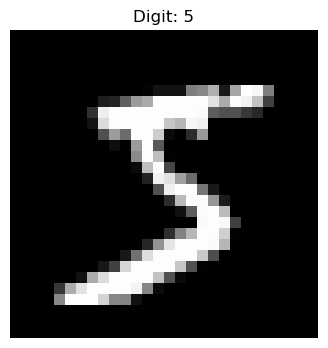

In [3]:
plt.figure(figsize=(4,4))
plt.imshow(X[0].reshape(28,28), cmap="gray")
plt.title(f"Digit: {y[0]}")
plt.axis("off")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=10000,random_state=42)
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (60000, 784)
Testing Images: (10000, 784)


In [5]:
rf = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [6]:
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9674


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       983
           1       0.99      0.99      0.99      1152
           2       0.94      0.97      0.96       967
           3       0.96      0.95      0.95      1034
           4       0.96      0.97      0.97       906
           5       0.98      0.96      0.97       937
           6       0.98      0.99      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.94      0.95      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



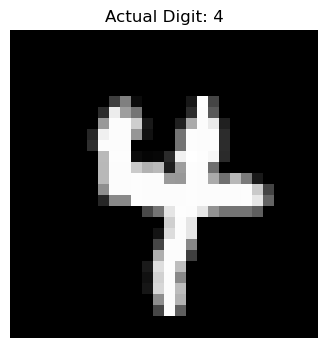

In [8]:
index = 1
image = X_test[index].reshape(28,28)
plt.figure(figsize=(4,4))
plt.imshow(image, cmap="gray")
plt.title(f"Actual Digit: {y_test[index]}")
plt.axis("off")
plt.show()

In [9]:
prediction = rf.predict(X_test[index].reshape(1,-1))
print("Actual Digit :", y_test[index])
print("Predicted Digit :", prediction[0])

Actual Digit : 4
Predicted Digit : 4


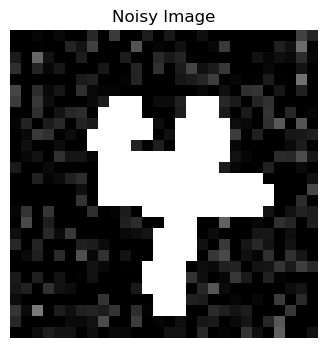

In [10]:
noisy_image = random_noise(image,mode="gaussian",var=0.02)
plt.figure(figsize=(4,4))
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.show()

In [11]:
prediction = rf.predict(
(noisy_image * 255).reshape(1, -1)
)
print("Prediction:", prediction[0])

Prediction: 4


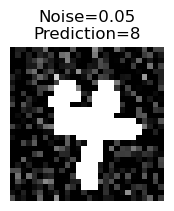

In [12]:
noise_levels = [0.00, 0.01, 0.03, 0.05]
for noise in noise_levels:
  noisy = random_noise(
  image,mode="gaussian",var=noise)
  pred = rf.predict(
  (noisy * 255).reshape(1, -1)
  )
plt.figure(figsize=(2,2))
plt.imshow(noisy, cmap="gray")
plt.title(f"Noise={noise}\nPrediction={pred[0]}")
plt.axis("off")
plt.show()

In [13]:
noise_values = [0.00, 0.01, 0.03, 0.05]
for noise in noise_values:
  noisy_test = []
  for img in X_test:
    img = img.reshape(28,28)
    noisy = random_noise(img,mode="gaussian",var=noise)
    noisy_test.append((noisy * 255).flatten())
  noisy_test = np.array(noisy_test)
  pred = rf.predict(noisy_test)
  acc = accuracy_score(y_test, pred)

  print(f"Noise Level {noise:.2f} -->; Accuracy = {acc:.4f}")

Noise Level 0.00 -->; Accuracy = 0.9621
Noise Level 0.01 -->; Accuracy = 0.7315
Noise Level 0.03 -->; Accuracy = 0.6725
Noise Level 0.05 -->; Accuracy = 0.6430
